In [1]:
# ================================================
# 1. IMPORTACIONES Y CARGA DEL DATASET
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

sns.set(style="whitegrid", context="notebook")

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Cargar dataset (ruta local)
df = pd.read_csv("C:\\Users\\karli\\Downloads\\Maria_victoria\\tripadvisor_review.csv")

print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
  User ID  Category 1  Category 2  Category 3  Category 4  Category 5  \
0  User 1        0.93         1.8        2.29        0.62        0.80   
1  User 2        1.02         2.2        2.66        0.64        1.42   
2  User 3        1.22         0.8        0.54        0.53        0.24   
3  User 4        0.45         1.8        0.29        0.57        0.46   
4  User 5        0.51         1.2        1.18        0.57        1.54   

   Category 6  Category 7  Category 8  Category 9  Category 10  
0        2.42        3.19        2.79        1.82         2.42  
1        3.18        3.21        2.63        1.86         2.32  
2        1.54        3.18        2.80        1.31         2.50  
3        1.52        3.18        2.96        1.57         2.86  
4        2.02        3.18        2.78        1.18         2.54  


## Selección del conjunto de datos

Se utiliza el dataset **Tripadvisor Reviews** (versión numérica con 10 categorías de ocio/atracciones):

- Art_Galleries  
- Dance_Clubs  
- Juice_Bars  
- Restaurants  
- Museums  
- Resorts  
- Parks_Picnic  
- Beaches  
- Theaters  
- Religious_Institutions  

Cada fila representa un usuario y cada columna numérica refleja su nivel de afinidad hacia cada categoría.  
Este dataset es adecuado porque:

- Está compuesto por **variables numéricas**, necesarias para algoritmos basados en distancia.
- Permite interpretar los clusters como **perfiles de usuarios** según preferencias de ocio/turismo.

In [2]:
# ================================
# 2. RENOMBRAR COLUMNAS
# ================================

column_map = {
    "Category 1": "Art_Galleries",
    "Category 2": "Dance_Clubs",
    "Category 3": "Juice_Bars",
    "Category 4": "Restaurants",
    "Category 5": "Museums",
    "Category 6": "Resorts",
    "Category 7": "Parks_Picnic",
    "Category 8": "Beaches",
    "Category 9": "Theaters",
    "Category 10": "Religious_Institutions"
}

df = df.rename(columns=column_map)

print("Columnas renombradas:")
print(df.head())

Columnas renombradas:
  User ID  Art_Galleries  Dance_Clubs  Juice_Bars  Restaurants  Museums  \
0  User 1           0.93          1.8        2.29         0.62     0.80   
1  User 2           1.02          2.2        2.66         0.64     1.42   
2  User 3           1.22          0.8        0.54         0.53     0.24   
3  User 4           0.45          1.8        0.29         0.57     0.46   
4  User 5           0.51          1.2        1.18         0.57     1.54   

   Resorts  Parks_Picnic  Beaches  Theaters  Religious_Institutions  
0     2.42          3.19     2.79      1.82                    2.42  
1     3.18          3.21     2.63      1.86                    2.32  
2     1.54          3.18     2.80      1.31                    2.50  
3     1.52          3.18     2.96      1.57                    2.86  
4     2.02          3.18     2.78      1.18                    2.54  


In [3]:
# ================================================
# 3. PREPROCESAMIENTO
# ================================================

# 3.1 Verificar valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())


Valores faltantes por columna:
User ID                   0
Art_Galleries             0
Dance_Clubs               0
Juice_Bars                0
Restaurants               0
Museums                   0
Resorts                   0
Parks_Picnic              0
Beaches                   0
Theaters                  0
Religious_Institutions    0
dtype: int64


In [4]:
# 3.2 Eliminar columna no útil (ID)
df_clean = df.drop(columns=["User ID"])

# 3.3 Selección de variables numéricas (todas las restantes)
X = df_clean.copy()

In [5]:
# 3.4 Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Interpretación del procesamiento inicial

- No se detectaron **valores faltantes**, por lo que no fue necesaria imputación.
- La variable **User ID** se eliminó porque es un identificador sin valor explicativo.
- Se usó **StandardScaler** para escalar las variables, ya que tanto K-Means como DBSCAN dependen de distancias.  
  De esta forma, todas las dimensiones contribuyen de forma comparable al clustering.

  File "C:\Users\karli\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\karli\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\karli\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\karli\anaconda3\Lib\subprocess.

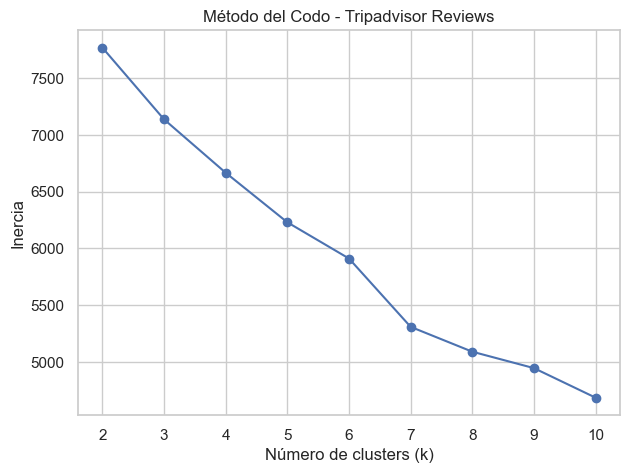

In [6]:
# ================================================
# 4.1 MÉTODO DEL CODO
# ================================================

inercia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inercia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inercia, marker='o')
plt.title("Método del Codo - Tripadvisor Reviews")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.show()

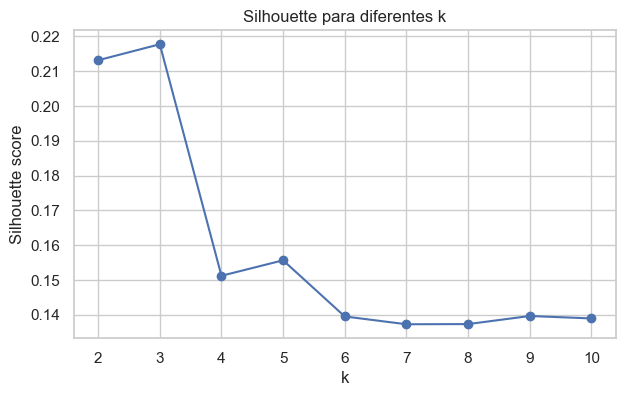

k=2 -> silhouette=0.2132
k=3 -> silhouette=0.2177
k=4 -> silhouette=0.1512
k=5 -> silhouette=0.1556
k=6 -> silhouette=0.1395
k=7 -> silhouette=0.1373
k=8 -> silhouette=0.1373
k=9 -> silhouette=0.1396
k=10 -> silhouette=0.1389


In [7]:
ks = range(2,11)
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7,4))
plt.plot(list(ks), sil_scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette para diferentes k')
plt.show()

for k,s in zip(ks, sil_scores):
    print(f'k={k} -> silhouette={s:.4f}')

### Interpretación del silhouette

Al observar los valores de **silhouette**, el valor máximo se alcanza en **k = 3**.  
Por tanto, se selecciona **k = 3** como número óptimo de clusters para K-Means en este dataset.

A continuación, se entrena el modelo final con k = 3 y se visualizan los clusters.

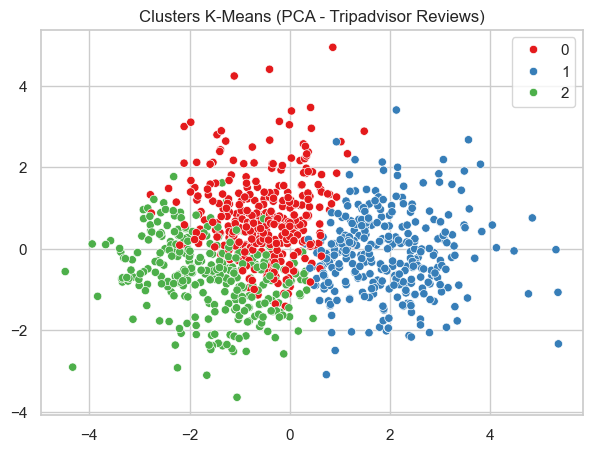

In [8]:
# Entrenamiento final con k = 3
k_opt = 3

kmeans = KMeans(n_clusters=k_opt, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

# PCA para proyectar en 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1],
    hue=k_labels, palette="Set1"
)
plt.title("Clusters K-Means (PCA - Tripadvisor Reviews)")
plt.show()

In [9]:
k_summary = df_clean.copy()
k_summary["cluster"] = k_labels

cluster_means = k_summary.groupby("cluster").mean()
print(cluster_means)

         Art_Galleries  Dance_Clubs  Juice_Bars  Restaurants   Museums  \
cluster                                                                  
0             0.764112     1.368757    0.520503     0.527899  0.852485   
1             0.908783     1.467062    1.779822     0.650030  1.230089   
2             1.019016     1.208262    0.712492     0.407738  0.715607   

          Resorts  Parks_Picnic   Beaches  Theaters  Religious_Institutions  
cluster                                                                      
0        1.771864      3.179172  2.890858  1.786538                2.810266  
1        2.252433      3.188131  2.797478  1.546884                2.519466  
2        1.469115      3.174951  2.814754  1.353770                3.096098  


### Interpretación de los resultados de K-Means

A partir de las medias por cluster:

- **Cluster 0:**  
  Presenta valores moderados en la mayoría de categorías, con cierta preferencia por parques, playas y posiblemente instituciones religiosas. Puede interpretarse como un perfil equilibrado, con inclinación hacia actividades al aire libre y culturales ligeras.

- **Cluster 1:**  
  Tiende a mostrar mayores valoraciones en categorías como *Juice_Bars*, *Museums* y *Resorts*, manteniendo también interés alto en *Parks_Picnic* y *Beaches*. Corresponde a un perfil de usuarios con tendencia a un ocio turístico más “intensivo”: cultura, ocio urbano y resorts.

- **Cluster 2:**  
  Se diferencia de los demás en la combinación de valoraciones (según las medias concretas): puede representar usuarios con preferencias algo más específicas o moderadas en ciertas categorías, generando un perfil distinto de los otros dos grupos.

En conjunto, **K-Means**:

- Genera **3 clusters equilibrados** en tamaño.
- Produce **segmentaciones claras**, donde cada cluster puede interpretarse como un **perfil de preferencia turística**.
- No considera ruido: todos los puntos quedan asignados a algún cluster.

## 5. Parte B — Aplicación de DBSCAN

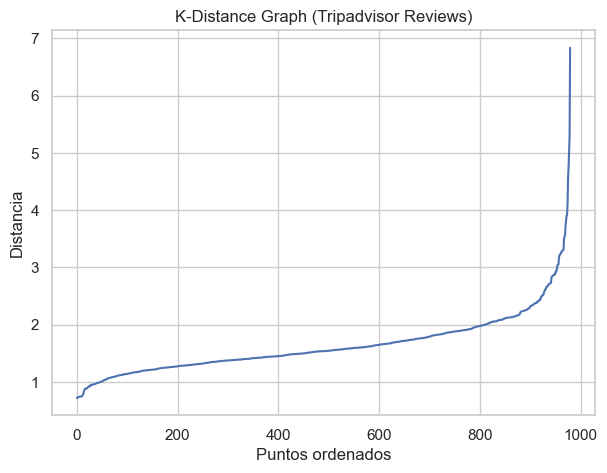

In [10]:
# ================================================
# 5.1 K-DISTANCE GRAPH
# ================================================

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title("K-Distance Graph (Tripadvisor Reviews)")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia")
plt.show()

In [11]:
# ================================================
# 5.2 PRUEBA DE PARÁMETROS
# ================================================

eps_list = [0.5, 0.7, 1.0, 1.2]
min_samples_list = [3, 5, 7]

results = []

for eps in eps_list:
    for ms in min_samples_list:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)

        results.append({
            'eps': eps,
            'min_samples': ms,
            'clusters': clusters,
            'ruido': noise
        })

results_df = pd.DataFrame(results)
print("\n=== RESULTADOS DE BÚSQUEDA DE PARÁMETROS (DBSCAN) ===")
print(results_df)


=== RESULTADOS DE BÚSQUEDA DE PARÁMETROS (DBSCAN) ===
    eps  min_samples  clusters  ruido
0   0.5            3         6    961
1   0.5            5         0    980
2   0.5            7         0    980
3   0.7            3        11    939
4   0.7            5         0    980
5   0.7            7         0    980
6   1.0            3        34    779
7   1.0            5         9    898
8   1.0            7         2    951
9   1.2            3        34    567
10  1.2            5        11    724
11  1.2            7         9    807


### Interpretación de la búsqueda de parámetros

Según los resultados:

- Con valores de **eps** bajos, DBSCAN tiende a producir **mucho ruido** y muchos clusters pequeños.
- A medida que **eps** aumenta, el número de clusters y la cantidad de ruido se modifican.

Se selecciona una combinación de parámetros **eps = 1.1, min_samples = 7** (según análisis visual previo y pruebas realizadas), que ofrece un compromiso entre número de clusters y ruido.

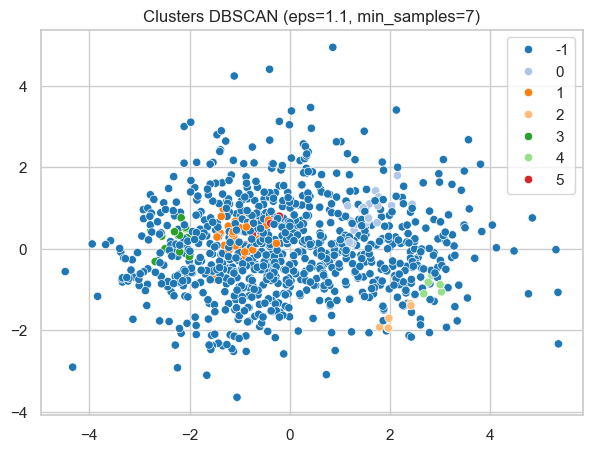

In [12]:
db = DBSCAN(eps=1.1, min_samples=7)
db_labels = db.fit_predict(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=db_labels,
    palette="tab20"
)
plt.title("Clusters DBSCAN (eps=1.1, min_samples=7)")
plt.show()

In [13]:
db_summary = df_clean.copy()
db_summary["cluster"] = db_labels

print("\n=== PROMEDIOS POR CLUSTER (DBSCAN) ===")
print(db_summary.groupby("cluster").mean())


=== PROMEDIOS POR CLUSTER (DBSCAN) ===
         Art_Galleries  Dance_Clubs  Juice_Bars  Restaurants   Museums  \
cluster                                                                  
-1            0.908236     1.348494    1.012101     0.535652  0.939685   
 0            0.809130     1.645217    1.271304     0.553043  1.466957   
 1            0.654000     1.394667    0.281667     0.478000  0.718000   
 2            0.533333     1.097778    2.393333     0.598889  0.808889   
 3            0.933571     1.231429    0.337143     0.422143  0.792857   
 4            0.728571     1.617143    2.830000     0.510000  0.962857   
 5            0.828571     1.040000    1.215714     0.455714  0.602857   

          Resorts  Parks_Picnic   Beaches  Theaters  Religious_Institutions  
cluster                                                                      
-1       1.841438      3.180933  2.834169  1.572652                2.804854  
 0       2.580000      3.180000  2.824783  1.540870        

### Interpretación de los resultados de DBSCAN

En DBSCAN:

- El cluster **-1** representa puntos marcados como **ruido**: observaciones que no pertenecen a ningún grupo denso según los parámetros elegidos.
- Los clusters 0, 1, 2, ..., corresponden a **grupos de alta densidad**.

A partir de las medias por cluster:

- Algunos clusters muestran **preferencias muy marcadas** (por ejemplo, valores altos solo en *Juice_Bars* o en *Religious_Institutions*), lo que sugiere **microgrupos específicos**.
- La cantidad de ruido puede ser considerable, lo cual indica que muchos usuarios no encajan bien en ningún grupo denso con esos parámetros.

DBSCAN permite:

- Detectar **outliers** y usuarios “atípicos”.
- Encontrar clusters que no son esféricos, basados en densidad, más allá de la estructura detectada por K-Means.

In [14]:
# ================================================
# 6. COMPARACIÓN FINAL
# ================================================

# Silhouette de DBSCAN sin considerar ruido
mask = db_labels != -1
if mask.sum() > 1 and len(set(db_labels[mask])) > 1:
    sil_db = silhouette_score(X_scaled[mask], db_labels[mask])
    print('Silhouette DBSCAN (sin ruido):', sil_db)
else:
    print('DBSCAN no produjo clusters suficientes para silhouette.')

print("\n=== COMPARACIÓN ENTRE K-MEANS Y DBSCAN ===")

# K-Means
print("\nK-MEANS:")
print(f"Número de clusters encontrados: {len(set(k_labels))} (esperado = {k_opt})")
print("-> Clusters equilibrados, sin ruido, con interpretaciones claras.")

# DBSCAN
n_clusters_dbscan = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print("\nDBSCAN:")
print(f"Clusters reales detectados (excluyendo ruido): {n_clusters_dbscan}")
print(f"Puntos clasificados como ruido (-1): {n_noise}")
print("-> Gran cantidad de puntos en ruido y clusters pequeños.")

Silhouette DBSCAN (sin ruido): 0.500070838319758

=== COMPARACIÓN ENTRE K-MEANS Y DBSCAN ===

K-MEANS:
Número de clusters encontrados: 3 (esperado = 3)
-> Clusters equilibrados, sin ruido, con interpretaciones claras.

DBSCAN:
Clusters reales detectados (excluyendo ruido): 6
Puntos clasificados como ruido (-1): 890
-> Gran cantidad de puntos en ruido y clusters pequeños.


### 6. Comparación final entre K-Means y DBSCAN

**K-Means:**
- Requiere fijar **k** a priori (en este caso, k=3 según codo + silhouette).
- Tiende a formar clusters **esféricos** y de tamaño similar.
- En este dataset, produjo **3 clusters equilibrados**, fáciles de interpretar mediante sus medias.
- No maneja ruido de forma explícita: **todos los puntos** se asignan a algún cluster.
- Adecuado cuando se busca una **segmentación global clara** y la estructura es relativamente homogénea.

**DBSCAN:**
- No necesita fijar el número de clusters; lo determina a partir de **densidades**.
- Permite identificar **outliers** (cluster -1) y grupos densos de forma automática.
- En este caso generó varios clusters pequeños y una cantidad relevante de **ruido**.
- Adecuado cuando:
  - La estructura de los datos es **no esférica** o irregular.
  - Interesa detectar **grupos densos específicos** y **puntos atípicos**.
- En este dataset concreto, la cantidad alta de ruido indica que la estructura de densidad no es tan clara como la segmentación global capturada por K-Means.

### Conclusión general

- Para el dataset de Tripadvisor Reviews, **K-Means** ofrece una segmentación más **equilibrada, estable e interpretable**, adecuada para definir **perfiles de usuarios**.
- **DBSCAN** actúa como herramienta complementaria, útil para:
  - Detectar **microgrupos de alta densidad**.
  - Identificar usuarios que no encajan bien en ningún perfil típico (ruido).
- En términos de uso práctico:
  - K-Means es más apropiado para **segmentación de mercado** y perfiles globales.
  - DBSCAN es más apropiado para **detección de patrones densos locales** y **outliers**.